# Gene Expression log2FoldChange Prediction with PyTorch (Generated by Claude)

**Goal:** predict `log2FoldChange` from gene/sequence features using a small MLP.

**Important context for this dataset (~384 rows used for training):**
- This is a *small-data* regime for a neural network. A network can easily memorize 384 rows.
- We use **K-Fold cross-validation** instead of one train/test split, because a single holdout
  of ~40-80 genes is too small to give a trustworthy estimate of performance.
- We use a **small architecture** + dropout + weight decay + early stopping to fight overfitting.
- We include a **linear regression baseline** at the end. For data this small, a simple model
  often matches or beats a neural net — it's worth knowing if that's true here before you
  trust the NN's predictions.

**Replace the placeholder column names in the `COLUMNS` cell below with your actual CSV headers.**


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 2. Load data and define columns

**Edit `COLUMNS` to match your actual CSV header names.** Based on what you described:
gene name, log2FoldChange, pvalue, log pvalue, sequence length, first 3 bases, last 3 bases, GC%, AT%.


In [2]:
CSV_PATH = "PAO1.csv"  # <-- change this to your file path

COLUMNS = {
    "gene_name": "gene_name",          # identifier, not used as a feature
    "target": "log2FoldChange",        # what we're predicting
    "pvalue": "pvalue",
    "log_pvalue": "log_pvalue",
    "seq_length": "Sequence_Length",
    "first3": "First_3",                # e.g. "ATG"
    "last3": "Last_3",                  # e.g. "TGA"
    "gc_pct": "GC_pct",
    "at_pct": "AT_pct",
}

df_full = pd.read_csv(CSV_PATH)
print(df_full.shape)
df_full.head()


(768, 9)


,gene_name,log2FoldChange,pvalue,log_pvalue,Sequence_Length,First_3,Last_3,GC_pct,AT_pct
0,PA2757,-6.867491,1.320000e-35,34.881054,444,GTG,TGA,65.09,34.91
1,PA3773,-4.212750,1.061225e-02,1.974193,1158,ATG,TGA,72.28,27.72
2,PA2506,-2.720020,1.952812e-02,1.709339,219,ATG,TGA,64.84,35.16
3,pvcD,-2.347189,2.691104e-02,1.570069,648,ATG,TAG,73.61,26.39
4,PA5460,-2.316146,4.940000e-14,13.306190,213,ATG,TGA,60.56,39.44


## 3. Use only half the data

You mentioned you only want to use half of the 768 rows for now (~384 rows).
We take a **random** half rather than the first half, in case the CSV is sorted
by some variable (e.g. by p-value or fold-change) — sorting bias would skew training.


In [3]:
rng = np.random.default_rng(SEED)
shuffled_idx = rng.permutation(len(df_full))
half = len(df_full) // 2
use_idx = shuffled_idx[:half]
unused_idx = shuffled_idx[half:]

df = df_full.iloc[use_idx].reset_index(drop=True)
_df_unused_half = df_full.iloc[unused_idx].reset_index(drop=True)

print("Rows used for training/eval:", df.shape[0])
print("Rows set aside (unused for now):", _df_unused_half.shape[0])


Rows used for training/eval: 384
Rows set aside (unused for now): 384


## 4. Feature engineering

- Numeric features (`pvalue`, `log_pvalue`, `seq_length`, `gc_pct`, `at_pct`) are kept as-is for now
  and standardized later (inside each CV fold, to avoid leakage).
- `first3` / `last3` are 3-letter DNA sequences (e.g. `"ATG"`). We one-hot encode **each position
  separately** (position 1, 2, 3 × bases A/C/G/T), rather than one-hot encoding the whole 3-letter
  string as a single category. This lets the network learn patterns like "position 1 = A matters"
  rather than treating "ATG" and "ATC" as completely unrelated categories.
- `gc_pct` and `at_pct` are likely close to complementary (GC% + AT% ≈ 100%). We keep both for now
  since real data sometimes has N bases or rounding, but flag this as a possible redundant feature
  to drop later if you see collinearity issues.


In [4]:
BASES = ["A", "C", "G", "T"]

def one_hot_positions(series, prefix):
    """One-hot encode a column of 3-letter strings into 12 binary columns
    (3 positions x 4 bases)."""
    out = pd.DataFrame(index=series.index)
    for pos in range(3):
        for base in BASES:
            col_name = f"{prefix}_pos{pos+1}_{base}"
            out[col_name] = (series.str.upper().str[pos] == base).astype(int)
    return out

first3_oh = one_hot_positions(df[COLUMNS["first3"]], "first3")
last3_oh = one_hot_positions(df[COLUMNS["last3"]], "last3")

numeric_cols = [COLUMNS["pvalue"], COLUMNS["log_pvalue"], COLUMNS["seq_length"],
                COLUMNS["gc_pct"], COLUMNS["at_pct"]]

X = pd.concat([df[numeric_cols].reset_index(drop=True),
               first3_oh.reset_index(drop=True),
               last3_oh.reset_index(drop=True)], axis=1)

y = df[COLUMNS["target"]].values.astype(np.float32)

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (384, 29)


,pvalue,log_pvalue,Sequence_Length,GC_pct,AT_pct,first3_pos1_A,first3_pos1_C,first3_pos1_G,first3_pos1_T,first3_pos2_A,...,last3_pos1_G,last3_pos1_T,last3_pos2_A,last3_pos2_C,last3_pos2_G,last3_pos2_T,last3_pos3_A,last3_pos3_C,last3_pos3_G,last3_pos3_T
0,0.045437,1.342592,1245,71.33,28.67,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
1,0.043034,1.366192,1695,65.84,34.16,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
2,0.000161,3.794361,630,63.49,36.51,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
3,0.044955,1.347222,2196,69.26,30.74,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
4,0.011310,1.946553,6375,72.22,27.78,1,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0


## 5. Helper functions (replacing sklearn utilities)

Pure numpy/PyTorch versions of the three small utilities we'd otherwise get from sklearn:
standardizing features, splitting indices into K folds, and computing MAE/RMSE/R².


In [5]:
class StandardScaler:
    """Minimal standardization: (x - mean) / std, fit on training data only."""
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0  # avoid divide-by-zero for constant columns
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


def kfold_indices(n_samples, n_splits, seed=SEED):
    """Yields (train_idx, val_idx) for n_splits folds, shuffled."""
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_samples)
    fold_sizes = np.full(n_splits, n_samples // n_splits, dtype=int)
    fold_sizes[: n_samples % n_splits] += 1
    current = 0
    folds = []
    for size in fold_sizes:
        folds.append(indices[current:current + size])
        current += size
    for i in range(n_splits):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != i])
        yield train_idx, val_idx


def mae_score(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse_score(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


## 6. PyTorch Dataset


In [6]:
class GeneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


## 7. Model definition

Small network on purpose: 2 hidden layers (32 -> 16 units), dropout, single linear output
neuron (regression, no activation on the final layer).


In [7]:
class GeneMLP(nn.Module):
    def __init__(self, input_dim, hidden1=32, hidden2=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


## 8. Training loop with early stopping

A single reusable function: trains on a train split, watches validation loss, stops when
validation loss stops improving, and restores the best-performing weights.


In [8]:
def train_one_fold(X_train, y_train, X_val, y_val, input_dim,
                    epochs=300, patience=20, lr=1e-3, weight_decay=1e-3, batch_size=32, verbose=False):
    train_ds = GeneDataset(X_train, y_train)
    val_ds = GeneDataset(X_val, y_val)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = GeneMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                val_losses.append(loss_fn(preds, yb).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"  early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss


## 9. K-Fold cross-validation

With only ~384 rows, we use 5-fold CV: each fold trains on ~307 rows and validates on ~77.
This gives 5 separate performance estimates we can average — far more trustworthy than one split.

Standardization is fit **only on the training fold** each time, then applied to that fold's
validation data, to avoid leaking validation-set statistics into training.


In [9]:
X_arr = X.values.astype(np.float32)
y_arr = y

N_FOLDS = 5

fold_results = []
fold_models = []
fold_splits = list(kfold_indices(len(X_arr), N_FOLDS))

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

    X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
    y_train, y_val = y_arr[train_idx], y_arr[val_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)

    model, history, best_val_loss = train_one_fold(
        X_train, y_train, X_val, y_val, input_dim=X_train.shape[1], verbose=True
    )

    model.eval()
    with torch.no_grad():
        val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()

    mae = mae_score(y_val, val_preds)
    rmse = rmse_score(y_val, val_preds)
    r2 = r2_score(y_val, val_preds)

    print(f"  Fold {fold_idx+1} -> MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    fold_results.append({"fold": fold_idx + 1, "mae": mae, "rmse": rmse, "r2": r2})
    fold_models.append((model, scaler))

results_df = pd.DataFrame(fold_results)
print("\n=== Cross-validation summary ===")
print(results_df)
print("\nMean MAE: {:.4f} +/- {:.4f}".format(results_df["mae"].mean(), results_df["mae"].std()))
print("Mean RMSE: {:.4f} +/- {:.4f}".format(results_df["rmse"].mean(), results_df["rmse"].std()))
print("Mean R2:   {:.4f} +/- {:.4f}".format(results_df["r2"].mean(), results_df["r2"].std()))


--- Fold 1/5 ---
  epoch   0  train_loss=0.7938  val_loss=0.7340
  epoch  20  train_loss=0.5566  val_loss=0.5454
  epoch  40  train_loss=0.5176  val_loss=0.5480
  early stopping at epoch 47
  Fold 1 -> MAE=0.6757  RMSE=0.7611  R2=0.2156
--- Fold 2/5 ---
  epoch   0  train_loss=0.6241  val_loss=1.6625
  epoch  20  train_loss=0.5484  val_loss=0.8578
  epoch  40  train_loss=0.5313  val_loss=0.8925
  epoch  60  train_loss=0.5151  val_loss=0.8470
  early stopping at epoch 68
  Fold 2 -> MAE=0.6893  RMSE=0.8159  R2=0.4260
--- Fold 3/5 ---
  epoch   0  train_loss=0.9094  val_loss=0.6018
  epoch  20  train_loss=0.6186  val_loss=0.5802
  early stopping at epoch 28
  Fold 3 -> MAE=0.6777  RMSE=0.7557  R2=-0.0046
--- Fold 4/5 ---
  epoch   0  train_loss=0.7990  val_loss=0.6836
  epoch  20  train_loss=0.5985  val_loss=0.5906
  epoch  40  train_loss=0.5118  val_loss=0.5824
  early stopping at epoch 57
  Fold 4 -> MAE=0.6690  RMSE=0.7601  R2=0.0949
--- Fold 5/5 ---
  epoch   0  train_loss=0.8976  va

## 10. Baseline: plain linear regression (numpy, closed-form)

Worth checking directly against the neural net. With ~384 rows and indirect features like GC%
and sequence length, it's plausible a simple linear model performs just as well — if so, that's
the more robust and interpretable choice for production use.

Implemented here via the normal equation (no sklearn): `w = (X^T X + lambda*I)^-1 X^T y`.
A small ridge penalty (`lambda`) is added for numerical stability since we have one-hot columns
that can be collinear.


In [10]:
def fit_linear_regression(X_train, y_train, ridge_lambda=1e-3):
    """Closed-form ridge regression. Returns weights (including bias term)."""
    X_aug = np.hstack([np.ones((X_train.shape[0], 1)), X_train])  # add bias column
    n_features = X_aug.shape[1]
    reg = ridge_lambda * np.eye(n_features)
    reg[0, 0] = 0  # don't regularize the bias term
    w = np.linalg.solve(X_aug.T @ X_aug + reg, X_aug.T @ y_train)
    return w

def predict_linear(X, w):
    X_aug = np.hstack([np.ones((X.shape[0], 1)), X])
    return X_aug @ w

lr_fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
    y_train, y_val = y_arr[train_idx], y_arr[val_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)

    w = fit_linear_regression(X_train, y_train)
    preds = predict_linear(X_val, w)

    mae = mae_score(y_val, preds)
    rmse = rmse_score(y_val, preds)
    r2 = r2_score(y_val, preds)
    lr_fold_results.append({"fold": fold_idx + 1, "mae": mae, "rmse": rmse, "r2": r2})

lr_results_df = pd.DataFrame(lr_fold_results)
print("=== Linear regression baseline (cross-validated) ===")
print(lr_results_df)
print("\nMean MAE: {:.4f}".format(lr_results_df["mae"].mean()))
print("Mean RMSE: {:.4f}".format(lr_results_df["rmse"].mean()))
print("Mean R2:   {:.4f}".format(lr_results_df["r2"].mean()))

print("\n=== NN vs Linear baseline (mean across folds) ===")
print(f"NN     MAE={results_df['mae'].mean():.4f}  R2={results_df['r2'].mean():.4f}")
print(f"Linear MAE={lr_results_df['mae'].mean():.4f}  R2={lr_results_df['r2'].mean():.4f}")


=== Linear regression baseline (cross-validated) ===
   fold       mae      rmse        r2
0     1  0.689455  0.766299  0.204924
1     2  0.689955  0.781225  0.473812
2     3  0.677364  0.775182 -0.057129
3     4  0.673705  0.762602  0.088986
4     5  0.667412  0.723545  0.133042

Mean MAE: 0.6796
Mean RMSE: 0.7618
Mean R2:   0.1687

=== NN vs Linear baseline (mean across folds) ===
NN     MAE=0.6637  R2=0.1950
Linear MAE=0.6796  R2=0.1687


## 11. Plot training curves (last fold, as an example)

Useful for sanity-checking that the model isn't wildly overfitting (train loss dropping while
val loss rises is the classic overfitting signature).


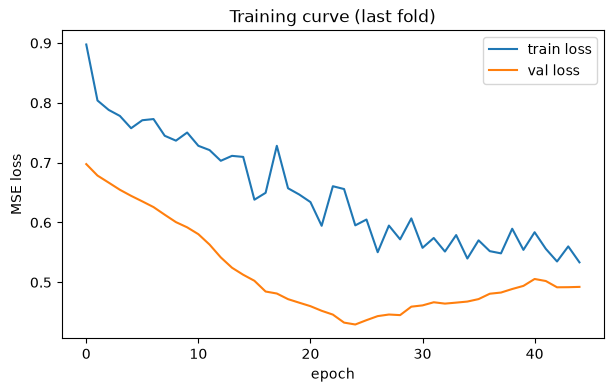

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("Training curve (last fold)")
plt.legend()
plt.show()


## 12. Predicted vs actual (all folds combined, out-of-fold predictions)

This is the most honest plot to look at: every point here is a prediction made on data the
model did NOT see during training (since it's from that point's validation fold).


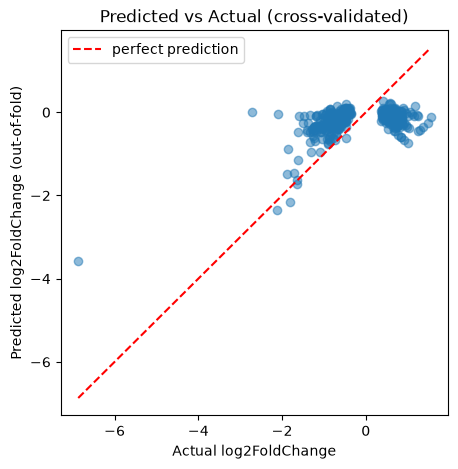

In [12]:
all_val_idx = []
all_val_preds = []
all_val_true = []

for (model, scaler), (train_idx, val_idx) in zip(fold_models, fold_splits):
    X_val = scaler.transform(X_arr[val_idx])
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    all_val_idx.extend(val_idx)
    all_val_preds.extend(preds)
    all_val_true.extend(y_arr[val_idx])

plt.figure(figsize=(5, 5))
plt.scatter(all_val_true, all_val_preds, alpha=0.5)
lims = [min(all_val_true + all_val_preds), max(all_val_true + all_val_preds)]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual log2FoldChange")
plt.ylabel("Predicted log2FoldChange (out-of-fold)")
plt.title("Predicted vs Actual (cross-validated)")
plt.legend()
plt.show()


## 13. Next steps / notes

- **If linear regression matches or beats the NN**, that's a real and useful finding for data
  this size — consider using it as your production model, or at least your baseline to beat
  before investing more in the NN.
- **The unused other half of the data** (`_df_unused_half`) is sitting there if you want to bring
  it in later as a genuine held-out test set, completely untouched by any of this CV process.
- If you add more features later (e.g. promoter motifs, expression in other conditions), rebuild
  `X` accordingly — the rest of the pipeline (scaling, CV, training loop) doesn't need to change.
- If `gc_pct` and `at_pct` turn out to be ~100% complementary in your real data, consider dropping
  one of them to reduce redundant/collinear features.
